# **K-Means Clustering Assignment By Rasha**

# KMeans Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Dog Horse KMeans Challenge

In [2]:
# Import Data
df_dh = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/dog_or_horse.csv")
# We picked variables that we need
X = df_dh[['height', 'weight']]
df_dh.head()

,height,weight,target,type
0,27.0,71.0,0.0,dog
1,27.0,92.0,0.0,dog
2,32.0,47.0,0.0,dog
3,30.0,90.0,0.0,dog
4,28.0,91.0,0.0,dog


In [3]:
# Scale Data
sc = StandardScaler()

# Fit & transform data.
X_sc = sc.fit_transform(X)


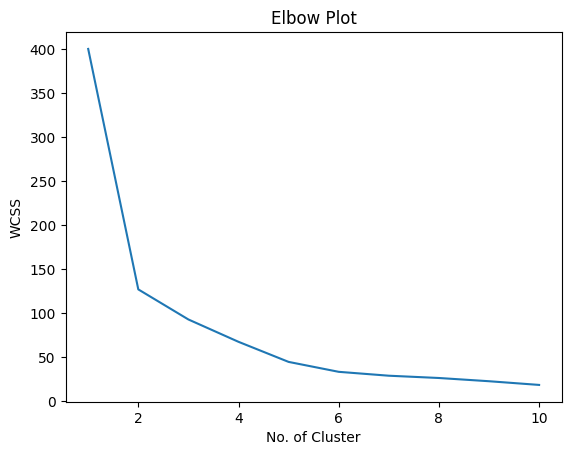

In [5]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []
# Note: We are using K-mean++ to avoid the random initialization trap 
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia 

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_sc)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.title('Elbow Plot')
plt.xlabel('No. of Cluster')
plt.ylabel('WCSS')

plt.show()

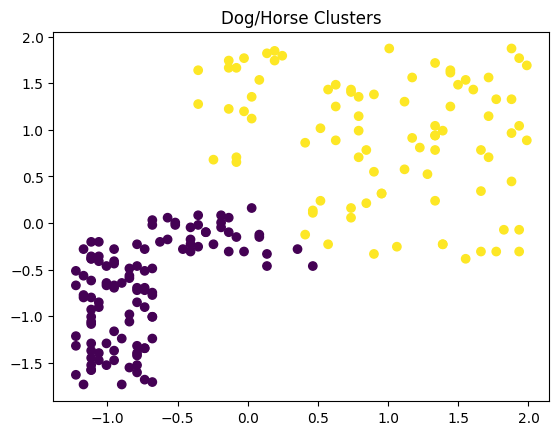

In [6]:
# Apply KMeans and Plot KMeans Results and Actual Results
# Apply KMeans and Plot KMeans Results and Actual Results

kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_sc)

plt.scatter(X_sc[:,0], X_sc[:,1], c=y_kmeans)
plt.title('Dog/Horse Clusters')
plt.show()

In [7]:
print(y_kmeans)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1]


In [8]:
# Cluster centeriods
print (kmeans.cluster_centers_)

[[-0.74395174 -0.70626086]
 [ 0.96628215  0.91732732]]


In [9]:
# assign the y_kmeans to a new column in the dataset
df_dh['kmean_prid']= y_kmeans
df_dh

,height,weight,target,type,kmean_prid
0,27.0,71.0,0.0,dog,0
1,27.0,92.0,0.0,dog,0
2,32.0,47.0,0.0,dog,0
3,30.0,90.0,0.0,dog,0
4,28.0,91.0,0.0,dog,0
...,...,...,...,...,...
195,55.0,140.0,1.0,horse,1
196,82.0,179.0,1.0,horse,1
197,46.0,132.0,1.0,horse,1
198,56.0,89.0,1.0,horse,0


### Plot the clusters including the centroid for each of the clusters as defined by K-Means

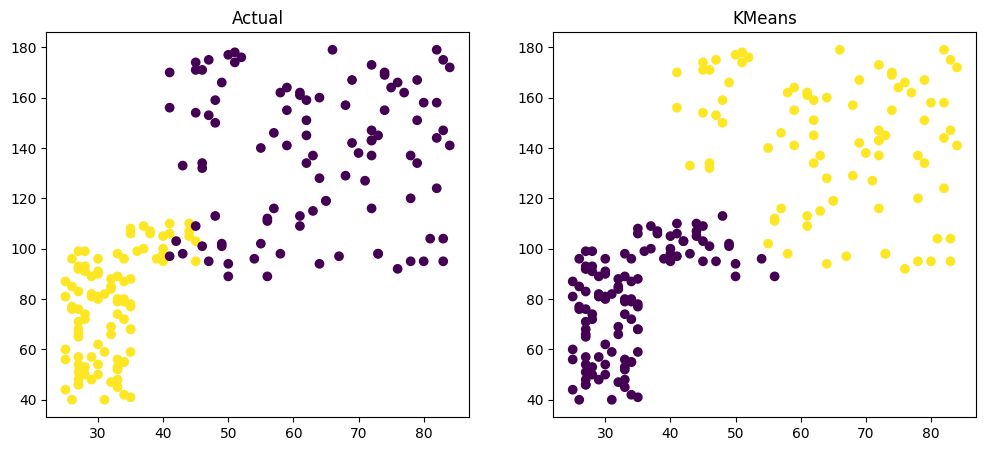

In [10]:
# Create a scatter plot of the actual results and the KMeans results

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].scatter(df_dh['height'], df_dh['weight'],
              c=df_dh['type'].map({'dog':1,'horse':0}))
ax[0].set_title('Actual')

ax[1].scatter(df_dh['height'], df_dh['weight'],
              c=df_dh['kmean_prid'])
ax[1].set_title('KMeans')

plt.show()


In [ ]:
# replace dog with 1 and horse with 0 to help us caluclate the Accuracy Score

df_dh['type'] = df_dh['type'].map({'dog':1,'horse':0})

# align cluster labels with true labels
# if accuracy_score(df_dh['type'], df_dh['kmean_prid']) < 0.5:
#     df_dh['kmean_prid'] = 1 - df_dh['kmean_prid']

In [ ]:
# Calculate the number of correct predictionsz
(df_dh['type'] == df_dh['kmean_prid']).value_counts()

False    200
Name: count, dtype: int64

In [28]:
# Compute Accuracy Score of KMean Labels with True Labels
accuracy_score(df_dh['type'], df_dh['kmean_prid'])*100

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/externals/array_api_compat/numpy/_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


ValueError: Input y_true contains NaN.

# Seattle Weather KMeans Challenge

In [14]:
df_sea = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/seattle_weather_1948-2017.csv")
X_sea = df_sea[['tmax', 'tmin']]
df_sea.head()

,ds,prcp,tmax,tmin,rain
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [15]:
# Scale Data
sc_sea = StandardScaler()

# Fit & transform data.
X_sea_sc = sc_sea.fit_transform(X_sea)

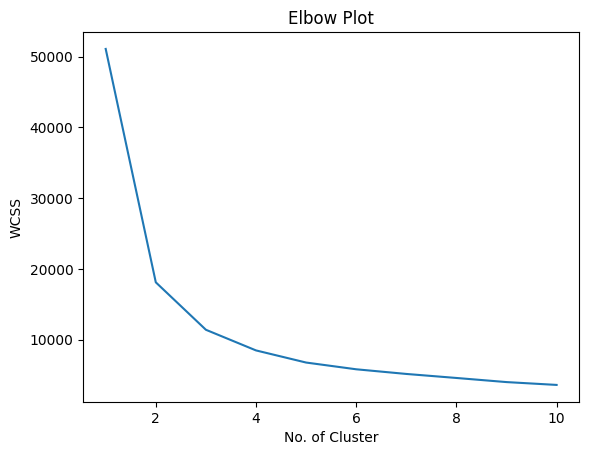

In [16]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []
# Note: We are using K-mean++ to avoid the random initialization trap 
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia 

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_sea_sc)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title('Elbow Plot')
plt.xlabel('No. of Cluster')
plt.ylabel('WCSS')
plt.show()

# From the plot we can see that the optimal number of clusters in 4, but our target is 2 so we should pick 2.

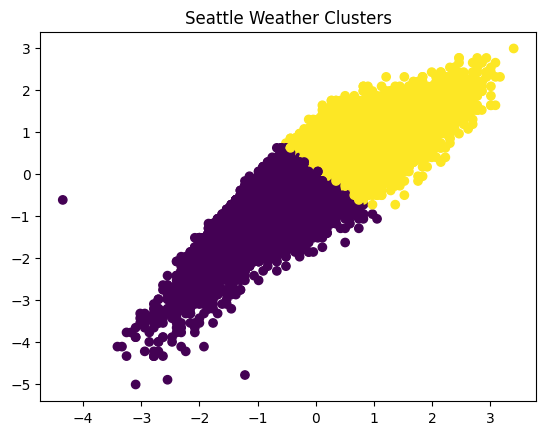

In [17]:
# Apply KMeans and Plot KMeans Results and Actual Results

kmeans_sea = KMeans(n_clusters=2, init='k-means++', random_state=42)
y_sea_kmeans = kmeans_sea.fit_predict(X_sea_sc)

plt.scatter(X_sea_sc[:,0], X_sea_sc[:,1], c=y_sea_kmeans)
plt.title('Seattle Weather Clusters')
plt.show()

In [18]:
print(y_sea_kmeans)

[0 0 0 ... 0 0 0]


In [19]:
# assign the y_kmeans to a new column
df_sea['kmean_sea_prid']= y_sea_kmeans
df_sea

,ds,prcp,tmax,tmin,rain,kmean_sea_prid
0,1948-01-01,0.47,51,42,True,0
1,1948-01-02,0.59,45,36,True,0
2,1948-01-03,0.42,45,35,True,0
3,1948-01-04,0.31,45,34,True,0
4,1948-01-05,0.17,45,32,True,0
...,...,...,...,...,...,...
25546,2017-12-10,0.00,49,34,False,0
25547,2017-12-11,0.00,49,29,False,0
25548,2017-12-12,0.00,46,32,False,0
25549,2017-12-13,0.00,48,34,False,0


In [20]:
# replace True with 1 and False with 0 to help us caluclate the Accuracy Score
df_sea['rain'] = df_sea['rain'].map({True:1, False:0})

In [ ]:
# Calculate the number of correct predictions

(df_sea['rain'] == df_sea['kmean_sea_prid']).value_counts()

False    16284
True      9267
Name: count, dtype: int64

In [22]:
df_sea.dropna(subset = ['rain'], inplace=True)

In [23]:
df_sea['rain'].isna().sum()

np.int64(0)

### Plot the clusters including the centroid for each of the clusters as defined by K-Means

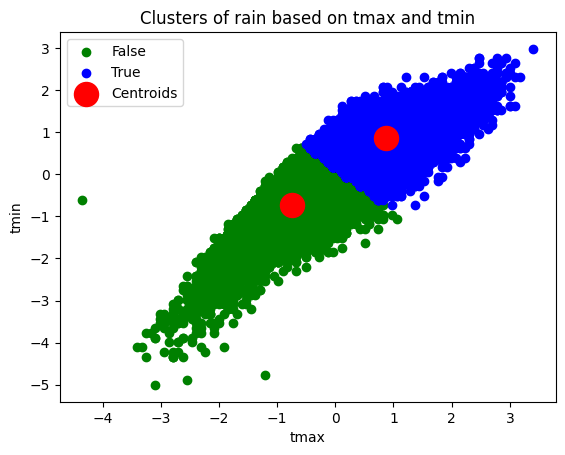

In [24]:
plt.figure()

plt.scatter(
    X_sea_sc[y_sea_kmeans == 0, 0],
    X_sea_sc[y_sea_kmeans == 0, 1],
    c='green',
    label='False'
)

plt.scatter(
    X_sea_sc[y_sea_kmeans == 1, 0],
    X_sea_sc[y_sea_kmeans == 1, 1],
    c='blue',
    label='True'
)

plt.scatter(
    kmeans_sea.cluster_centers_[:,0],
    kmeans_sea.cluster_centers_[:,1],
    c='red',
    s=300,
    label='Centroids'
)

plt.title('Clusters of rain based on tmax and tmin')
plt.xlabel('tmax')
plt.ylabel('tmin')
plt.legend()

plt.show()

In [32]:
# Compute Accuracy Score of KMean Labels with True Labels
(1-accuracy_score(df_sea['rain'], df_sea['kmean_sea_prid']))*100

63.727101925786755

# Random Blob KMeans Challenge

- You dont have true labels for this data so this is truly an unsupervised dataset
- The blobs are randomly generated every time you run the cell and their characteristics are:
    - 2000-4000 data points
    - 10-30 blobs created

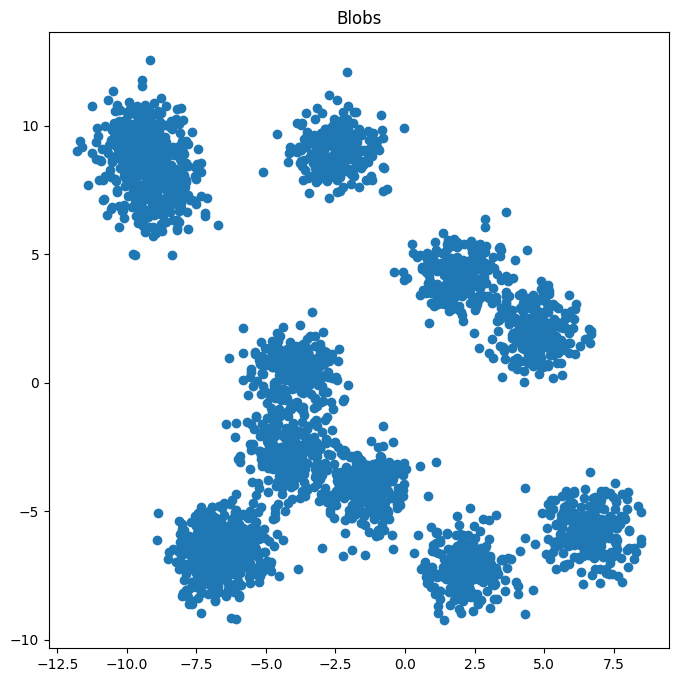

In [33]:
# Create blob dataset

X_blob, y_blob = make_blobs(
    n_samples=3000,
    centers=12,
    cluster_std=0.8,
    random_state=42
)

df_blob = pd.DataFrame(X_blob, columns=['x','y'])

plt.figure(figsize=(8,8))
plt.scatter(df_blob['x'], df_blob['y'])
plt.title('Blobs')
plt.show()

In [34]:
# Scale Data
sc_blb = StandardScaler()
# Fit & transform data.
X_blb_sc = sc.fit_transform(df_blob)

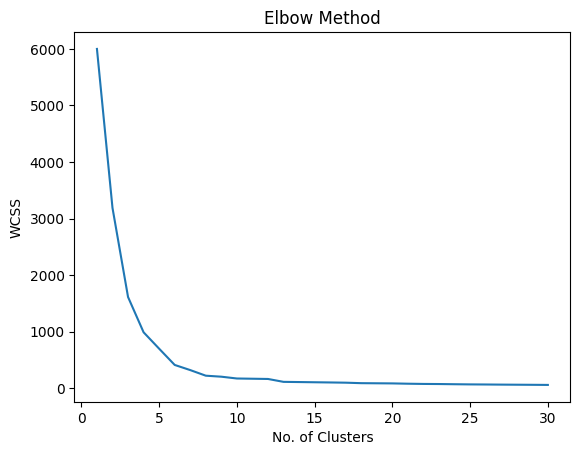

In [37]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []

wcss = []

for i in range(1,31):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_blb_sc)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,31), wcss)
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()
# Note: We are using K-mean++ to avoid the random initialization trap 
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia 


In [44]:
# Apply KMeans and Plot KMeans Results and Actual Results

kmeans_blb = KMeans(
    n_clusters=13,
    init='k-means++',
    random_state=42
)

y_blb_kmeans = kmeans_blb.fit_predict(X_blb_sc)


In [45]:
print(y_blb_kmeans)

[ 1  3  0 ... 10  6 11]


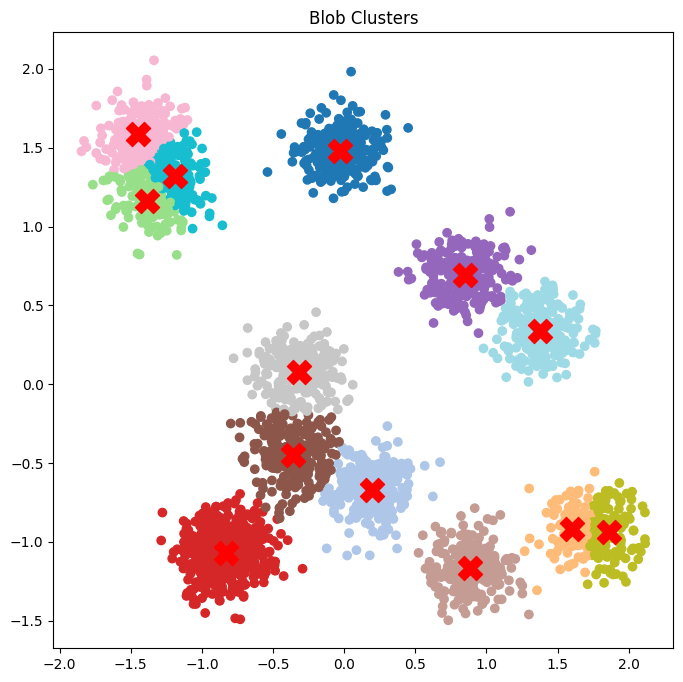

In [46]:
# Plot the clusters 

plt.figure(figsize=(8,8))

plt.scatter(
    X_blb_sc[:,0],
    X_blb_sc[:,1],
    c=y_blb_kmeans,
    cmap='tab20'
)

plt.scatter(
    kmeans_blb.cluster_centers_[:,0],
    kmeans_blb.cluster_centers_[:,1],
    s=300,
    c='red',
    marker='X'
)

plt.title('Blob Clusters')
plt.show()